<a href="https://colab.research.google.com/github/nightlurkr/FinalProjectAI-CekFresh/blob/main/fp_ai_kel8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ryanadya","key":"c63fd2418a030d2fd484e87843e76a1b"}'}

In [28]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API siap digunakan!")

Kaggle API siap digunakan!


In [29]:
# Download dataset 1: sriramr (pisang & jeruk)
!kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content/datasets/sriramr

# Download dataset 2: raghavrpotdar (tomat)
!kaggle datasets download -d raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables -p /content/datasets/raghavrpotdar

print("Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
fruits-fresh-and-rotten-for-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables
License(s): CC0-1.0
fresh-and-stale-images-of-fruits-and-vegetables.zip: Skipping, found more recently modified local copy (use --force to force download)
Download selesai!


In [30]:
import zipfile

with zipfile.ZipFile('/content/datasets/sriramr/fruits-fresh-and-rotten-for-classification.zip', 'r') as z:
    z.extractall('/content/datasets/sriramr/')

with zipfile.ZipFile('/content/datasets/raghavrpotdar/fresh-and-stale-images-of-fruits-and-vegetables.zip', 'r') as z:
    z.extractall('/content/datasets/raghavrpotdar/')

print("Ekstrak selesai!")

Ekstrak selesai!


In [31]:
# Melihat isi folder hasil ekstrak untuk memastikan strukturnya benar
for dataset in ['sriramr', 'raghavrpotdar']:
    print(f"\n=== Struktur {dataset} ===")
    for root, dirs, files in os.walk(f'/content/datasets/{dataset}'):
        level = root.replace(f'/content/datasets/{dataset}', '').count(os.sep)
        if level < 3:
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')


=== Struktur sriramr ===
sriramr/
  dataset/
    dataset/
    test/
    train/

=== Struktur raghavrpotdar ===
raghavrpotdar/
  stale_tomato/
  fresh_tomato/
  fresh_bitter_gourd/
  stale_bitter_gourd/
  stale_banana/
  stale_apple/
  stale_orange/
  fresh_banana/
  fresh_capsicum/
  fresh_apple/
  stale_capsicum/
  fresh_orange/


### EDA (Exploratory Data Analysis)

Melihat struktur lengkap kedua dataset

In [32]:
print("=== ISI DATASET SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr')):
    print(f"  {item}")

print("\n=== ISI DATASET RAGHAVRPOTDAR ===")
for item in sorted(os.listdir('/content/datasets/raghavrpotdar')):
    print(f"  {item}")

=== ISI DATASET SRIRAMR ===
  dataset
  fruits-fresh-and-rotten-for-classification.zip

=== ISI DATASET RAGHAVRPOTDAR ===
  ImageLabels.txt
  fresh-and-stale-images-of-fruits-and-vegetables.zip
  fresh_apple
  fresh_banana
  fresh_bitter_gourd
  fresh_capsicum
  fresh_orange
  fresh_tomato
  stale_apple
  stale_banana
  stale_bitter_gourd
  stale_capsicum
  stale_orange
  stale_tomato


untuk Raghavpotdae langsung terlihat struktur foldernya tapi untuk dataset siramr masih ada didalam folder `dataset` jadi selanjutnya mencoba untuk melihat isi dari folder dataset di sriramr.

In [33]:
print("=== ISI FOLDER DATASET/SRIRAMR ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset')):
    print(f"  {item}")

=== ISI FOLDER DATASET/SRIRAMR ===
  dataset
  test
  train


masih ada subfolder lagi dan terlihat bahwa sriramr strukturnya `dataset/dataset/train` dan `dataset/dataset/test` selanjutnya melihat satu level lagi untuk melihat isi dari folder train dan test di sriramr.

In [34]:
print("=== ISI FOLDER TRAIN ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/train')):
    print(f"  {item}")

print("\n=== ISI FOLDER TEST ===")
for item in sorted(os.listdir('/content/datasets/sriramr/dataset/dataset/test')):
    print(f"  {item}")

=== ISI FOLDER TRAIN ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges

=== ISI FOLDER TEST ===
  freshapples
  freshbanana
  freshoranges
  rottenapples
  rottenbanana
  rottenoranges


#### **Menghitung jumlah gambar per kelas di kedua dataset**

ini untuk mendeteksi jika ada class imbalance (ketidakseimbangan jumlah data antar kelas) sebelum proses training.

In [35]:
sriramr_base_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_base_test = '/content/datasets/sriramr/dataset/dataset/test'
raghavrpotdar_base = '/content/datasets/raghavrpotdar'

# Folder yang relevan dari masing-masing dataset
sriramr_folders = [
    'freshbanana', 'rottenbanana',
    'freshoranges', 'rottenoranges'
]

raghavrpotdar_folders = [
    'fresh_tomato', 'stale_tomato'
]

print("=== JUMLAH GAMBAR SRIRAMR (Train) ===")
for folder in sriramr_folders:
    path = os.path.join(sriramr_base_train, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR SRIRAMR (Test) ===")
for folder in sriramr_folders:
    path = os.path.join(sriramr_base_test, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

print("\n=== JUMLAH GAMBAR RAGHAVRPOTDAR ===")
for folder in raghavrpotdar_folders:
    path = os.path.join(raghavrpotdar_base, folder)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {folder}: {count} gambar")

=== JUMLAH GAMBAR SRIRAMR (Train) ===
  freshbanana: 1581 gambar
  rottenbanana: 2224 gambar
  freshoranges: 1466 gambar
  rottenoranges: 1595 gambar

=== JUMLAH GAMBAR SRIRAMR (Test) ===
  freshbanana: 381 gambar
  rottenbanana: 530 gambar
  freshoranges: 388 gambar
  rottenoranges: 403 gambar

=== JUMLAH GAMBAR RAGHAVRPOTDAR ===
  fresh_tomato: 981 gambar
  stale_tomato: 982 gambar


Hasil:

Pisang (sriramr):

- Train: fresh 1.581 + rotten 2.224 = 3.805 gambar
- Test: fresh 381 + rotten 530 = 911 gambar
- Total: fresh 1.581 & rotten 2.224, rasio: 71% **(kurang seimbang**)
- Data ini sedikit tidak seimbang karena selisihnya 643 gambar dimana rotten lebih banyak ±40% dari fresh

Jeruk (sriramr):

- Train: fresh 1.466 + rotten 1.595 = 3.061 gambar
- Test: fresh 388 + rotten 403 = 791 gambar
- Total: fresh 1.466 & rotten 1.595, rasio: 91,9% **(hampir seimbang)**

Tomat (raghavrpotdar):

- fresh 981 + stale 982 = 1.963 gambar
- rasio: 99,9% **(sangat seimbang)**

Total keseluruhan: ±10.531 gambar dimana ini adalah jumlah yang sangat cukup untuk fine-tuning MobileNetV2. Lalu karna sriramr sudah punya pembagian train dan test sendiri, sedangkan raghavrpotdar belum maka selanjutnya ini akan ditangani saat split data nanti.


#### **Visualisai Sample Gambar per Kelas**

 ini menampilkan satu gambar secara acak dari masing-masing kelas (fresh banana, rotten banana, fresh orange, rotten orange, fresh tomato, rotten tomato) dalam satu grid 2×3. Yang mana ini bertujuan untuk memverifikasi secara visual bahwa gambar bisa terbaca dengan benar, tidak korup, dan kualitasnya layak untuk digunakan dalam training.

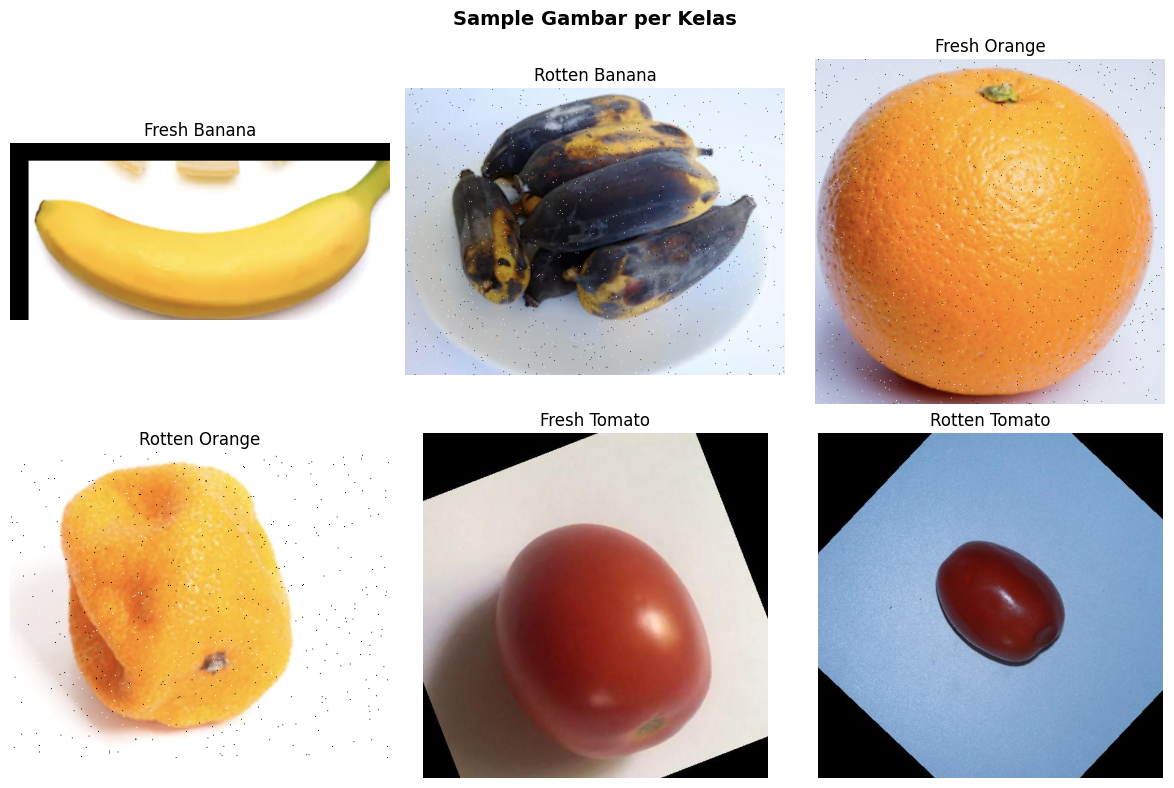

Tampilan sample gambar selesai!


In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

classes = {
    'Fresh Banana'  : '/content/datasets/sriramr/dataset/dataset/train/freshbanana',
    'Rotten Banana' : '/content/datasets/sriramr/dataset/dataset/train/rottenbanana',
    'Fresh Orange'  : '/content/datasets/sriramr/dataset/dataset/train/freshoranges',
    'Rotten Orange' : '/content/datasets/sriramr/dataset/dataset/train/rottenoranges',
    'Fresh Tomato'  : '/content/datasets/raghavrpotdar/fresh_tomato',
    'Rotten Tomato' : '/content/datasets/raghavrpotdar/stale_tomato',
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, path) in enumerate(classes.items()):
    images = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_img = random.choice(images)

    img = mpimg.imread(os.path.join(path, random_img))
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Tampilan sample gambar selesai!")

### Filter, Seleksi & Standarisasi Label

Karena kedua dataset punya struktur dan penamaan folder yang berbeda-beda. Sriramr pakai nama freshbanana, rottenoranges, dll. Raghavrpotdar pakai fresh_tomato, stale_tomato. Maka ini perlu untuk menyatukan semuanya ke dalam satu struktur folder yang seragam dengan label yang konsisten (fresh dan rotten), supaya nanti saat training model tidak bingung membaca datanya.

In [37]:
#membuat struktur folder
import shutil

base_output = '/content/datasets/final'

for split in ['train', 'val', 'test']:
    for label in ['fresh', 'rotten']:
        os.makedirs(f'{base_output}/{split}/{label}', exist_ok=True)

print("Struktur folder final berhasil dibuat!")
print("\nStruktur yang dibuat:")
for split in ['train', 'val', 'test']:
    print(f"  final/{split}/")
    for label in ['fresh', 'rotten']:
        print(f"    {label}/")

Struktur folder final berhasil dibuat!

Struktur yang dibuat:
  final/train/
    fresh/
    rotten/
  final/val/
    fresh/
    rotten/
  final/test/
    fresh/
    rotten/


#### **Mengcopy & standarisasi semua gambar ke folder final:**

In [38]:
import uuid

def copy_images(src_folder, dst_folder):

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in images:
        src_path = os.path.join(src_folder, img_name)
        new_name = f"{uuid.uuid4().hex}.jpg"
        dst_path = os.path.join(dst_folder, new_name)
        shutil.copy2(src_path, dst_path)

    return len(images)

# ============================================================
# SRIRAMR (Pisang & Jeruk)
# Sriramr sudah punya split train dan test sendiri
# Train dari sriramr → akan dimasukkan ke train final
# Test dari sriramr → akan dimasukkan ke test final
# ============================================================

sriramr_train = '/content/datasets/sriramr/dataset/dataset/train'
sriramr_test  = '/content/datasets/sriramr/dataset/dataset/test'

mapping_sriramr_train = {
    'freshbanana'   : 'fresh',
    'rottenbanana'  : 'rotten',
    'freshoranges'  : 'fresh',
    'rottenoranges' : 'rotten',
}

mapping_sriramr_test = {
    'freshbanana'   : 'fresh',
    'rottenbanana'  : 'rotten',
    'freshoranges'  : 'fresh',
    'rottenoranges' : 'rotten',
}

print("=== Menyalin gambar dari SRIRAMR (Train) ===")
for folder, label in mapping_sriramr_train.items():
    src = os.path.join(sriramr_train, folder)
    dst = os.path.join(base_output, 'train', label)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{label}: {count} gambar")

print("\n=== Menyalin gambar dari SRIRAMR (Test) ===")
for folder, label in mapping_sriramr_test.items():
    src = os.path.join(sriramr_test, folder)
    dst = os.path.join(base_output, 'test', label)
    count = copy_images(src, dst)
    print(f"  {folder} → test/{label}: {count} gambar")

# ============================================================
# RAGHAVRPOTDAR (Tomat)
# Raghavrpotdar belum punya split, jadi semua akan dimasukkan
# ke train dulu, nanti akan split manual di step berikutnya
# 'stale' = rotten, lalu standarisasi labelnya
# ============================================================

raghavrpotdar_base = '/content/datasets/raghavrpotdar'

mapping_raghavrpotdar = {
    'fresh_tomato' : 'fresh',
    'stale_tomato' : 'rotten',
}

print("\n=== Menyalin gambar dari RAGHAVRPOTDAR (Tomat) ===")
for folder, label in mapping_raghavrpotdar.items():
    src = os.path.join(raghavrpotdar_base, folder)
    dst = os.path.join(base_output, 'train', label)
    count = copy_images(src, dst)
    print(f"  {folder} → train/{label}: {count} gambar")

print("\nSemua gambar berhasil disalin dan label distandarisasi!")

=== Menyalin gambar dari SRIRAMR (Train) ===
  freshbanana → train/fresh: 1581 gambar
  rottenbanana → train/rotten: 2224 gambar
  freshoranges → train/fresh: 1466 gambar
  rottenoranges → train/rotten: 1595 gambar

=== Menyalin gambar dari SRIRAMR (Test) ===
  freshbanana → test/fresh: 381 gambar
  rottenbanana → test/rotten: 530 gambar
  freshoranges → test/fresh: 388 gambar
  rottenoranges → test/rotten: 403 gambar

=== Menyalin gambar dari RAGHAVRPOTDAR (Tomat) ===
  fresh_tomato → train/fresh: 981 gambar
  stale_tomato → train/rotten: 982 gambar

Semua gambar berhasil disalin dan label distandarisasi!


Jadi ini adalah proses standardisasi label. Fungsi `copy_images` menyalin gambar dari folder sumber ke folder tujuan sekaligus memberi nama file baru yang unik menggunakan UUID, sehingga tidak ada konflik nama antar dataset.

**Mapping label yang dilakukan:**

- freshbanana, freshoranges → fresh
- rottenbanana, rottenoranges, stale_tomato → rotten

Dataset raghavrpotdar (tomat) menggunakan istilah stale untuk busuk, sehingga di sini diubah menjadi rotten agar konsisten.

#### **Mengecek Distribusi Gambar Setelah Proses Copy sebelumnya**

In [39]:
print("=== DISTRIBUSI FOLDER FINAL SAAT INI ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    for label in ['fresh', 'rotten']:
        path = f'{base_output}/{split}/{label}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {label}: {count} gambar")
        total += count

print(f"\nTotal keseluruhan: {total} gambar")

=== DISTRIBUSI FOLDER FINAL SAAT INI ===

train/
  fresh: 7305 gambar
  rotten: 8735 gambar

val/
  fresh: 604 gambar
  rotten: 720 gambar

test/
  fresh: 1685 gambar
  rotten: 2013 gambar

Total keseluruhan: 21062 gambar


Hasil distribusinya sudah sesuai, tapi disini karena folder val masih kosong jadi ini perlu untuk split sebagian data jadi val dan juga Tomat dari raghavrpotdar belum punya bagian test jadi ini akan ditangani sekalian

#### **Split Data dan Memindahkan Gambar Tomat**

In [40]:
import random
import shutil

def move_images(src_folder, dst_folder, count):

    images = [f for f in os.listdir(src_folder)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.seed(42)
    selected = random.sample(images, count)

    for img_name in selected:
        src_path = os.path.join(src_folder, img_name)
        dst_path = os.path.join(dst_folder, img_name)
        shutil.move(src_path, dst_path)

    return count

# ============================================================
# Split:
# Train saat ini: fresh 4028, rotten 4801
# Disini akan mengambil 15% dari train untuk dijadikan val
# fresh : 15% x 4028 = 604 gambar
# rotten: 15% x 4801 = 720 gambar
# ============================================================

val_fresh_count  = int(0.15 * 4028)
val_rotten_count = int(0.15 * 4801)

print("=== Memindahkan gambar dari Train → Val ===")

count = move_images(
    f'{base_output}/train/fresh',
    f'{base_output}/val/fresh',
    val_fresh_count
)
print(f"  train/fresh → val/fresh: {count} gambar dipindahkan")

count = move_images(
    f'{base_output}/train/rotten',
    f'{base_output}/val/rotten',
    val_rotten_count
)
print(f"  train/rotten → val/rotten: {count} gambar dipindahkan")

# ============================================================
# Tomat dari raghavrpotdar belum punya bagian test
# Jadi akan mengambil 15% dari tomat yang ada di train untuk test
# Total tomat di train: fresh 981 + rotten 982
# 15% x 981 = 147, 15% x 982 = 147
# ============================================================

print("\n=== Memindahkan sebagian Tomat dari Train → Test ===")

# Tapi karena tomat sudah tercampur dengan buah lain di folder train
# jadi pakai jumlah proporsional (±147 gambar per kelas)
tomato_test_count = int(0.15 * 981)

count = move_images(
    f'{base_output}/train/fresh',
    f'{base_output}/test/fresh',
    tomato_test_count
)
print(f"  train/fresh → test/fresh (tomat): {count} gambar dipindahkan")

count = move_images(
    f'{base_output}/train/rotten',
    f'{base_output}/test/rotten',
    tomato_test_count
)
print(f"  train/rotten → test/rotten (tomat): {count} gambar dipindahkan")

print("\nSplit selesai!")

=== Memindahkan gambar dari Train → Val ===
  train/fresh → val/fresh: 604 gambar dipindahkan
  train/rotten → val/rotten: 720 gambar dipindahkan

=== Memindahkan sebagian Tomat dari Train → Test ===
  train/fresh → test/fresh (tomat): 147 gambar dipindahkan
  train/rotten → test/rotten (tomat): 147 gambar dipindahkan

Split selesai!


Jadi ditahap ini itu adalah proses:
1. Membuat validation set dengan mengambil 15% dari data train (±604 gambar fresh, ±720 gambar rotten) dan memindahkannya ke folder val/.
2. Membuat test set untuk tomat, karena dataset raghavrpotdar tidak memiliki split test bawaan, kita ambil 15% dari data tomat di train (±147 gambar per kelas) dan dipindahkan ke folder test/.

#### **Mengecek Distribusi Final Dataset**

In [41]:
print("=== DISTRIBUSI FINAL DATASET ===")
total = 0
for split in ['train', 'val', 'test']:
    print(f"\n{split}/")
    split_total = 0
    for label in ['fresh', 'rotten']:
        path = f'{base_output}/{split}/{label}'
        count = len([f for f in os.listdir(path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {label}: {count} gambar")
        total += count
        split_total += count
    print(f"  Subtotal: {split_total} gambar")

print(f"\nTotal keseluruhan: {total} gambar")

=== DISTRIBUSI FINAL DATASET ===

train/
  fresh: 6554 gambar
  rotten: 7868 gambar
  Subtotal: 14422 gambar

val/
  fresh: 1208 gambar
  rotten: 1440 gambar
  Subtotal: 2648 gambar

test/
  fresh: 1832 gambar
  rotten: 2160 gambar
  Subtotal: 3992 gambar

Total keseluruhan: 21062 gambar


Dataset final terdiri dari 10.531 gambar yang telah dibagi menjadi tiga split: **train (7.211)**, **val (1.324)**, dan **test (1.996)**

### Preprocessing

#### **Resize, Normalisasi & Augmentasi**

- Resize → MobileNetV2 hanya menerima input gambar ukuran 224×224 dan gambar dari dataset yang ada itu punya ukuran yang berbeda-beda, jadi harus diseragamkan
- Normalisasi → pixel value asli gambar berkisar 0–255, jadi akan diubah ke 0–1 agar model lebih mudah dan cepat belajar
- Augmentasi → khusus data train, akan ditambah variasi gambar secara artifisial (flip, rotasi, brightness) agar model lebih robust dan tidak overfitting

#### **Konfigurasi ImageDataGenerator**

In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi hanya diterapkan ke train, bukan val dan test
# karena val dan test digunakan untuk evaluasi kondisi nyata
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerator berhasil dikonfigurasi!")

ImageDataGenerator berhasil dikonfigurasi!


- **train_datagen** (untuk training) selain normalisasi pixel ke rentang 0–1, juga menerapkan augmentasi data: flip horizontal, rotasi ±15°, variasi kecerahan 80–120%, dan zoom 10%. Augmentasi ini membuat model lebih robust dengan melihat variasi gambar yang lebih beragam.
- **val_test_datagen** (untuk validasi & test) hanya normalisasi saja, tanpa augmentasi. Ini penting agar evaluasi dilakukan pada kondisi gambar yang natural/asli.

#### **Load dataset menggunakan generator**

In [43]:
IMG_SIZE  = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    f'{base_output}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=42
)

test_generator = val_test_datagen.flow_from_directory(
    f'{base_output}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"  → Label 'fresh' = {train_generator.class_indices['fresh']}")
print(f"  → Label 'rotten' = {train_generator.class_indices['rotten']}")

Found 14422 images belonging to 2 classes.
Found 2648 images belonging to 2 classes.
Found 3992 images belonging to 2 classes.

Class indices: {'fresh': 0, 'rotten': 1}
  → Label 'fresh' = 0
  → Label 'rotten' = 1


Jadi ini adalah proses yang menghubungkan generator ke folder dataset. Ukuran gambar di resize otomatis ke 224×224 piksel sesuai standar input MobileNetV2. class_mode='binary' digunakan karena hanya ada 2 kelas (fresh = 0, rotten = 1). Generator train di shuffle tiap epoch, sedangkan val dan test tidak perlu diacak karena hanya untuk evaluasi.

dari hasil output:
- Fresh = 0, Rotten = 1 — label sudah terdefinisi dengan benar
- Jumlah gambar juga sudah sesuai distribusi tadi

#### **Hasil Preprocessing Secara Visual**

=== VERIFIKASI PREPROCESSING ===
Shape batch: (32, 224, 224, 3)
  → 32 gambar, ukuran 224x224, 3 channel (RGB)

Nilai pixel min : 0.0000  (seharusnya mendekati 0)
Nilai pixel max : 1.0000  (seharusnya mendekati 1)

Distribusi label dalam batch ini:
  Fresh  (0): 13 gambar
  Rotten (1): 19 gambar


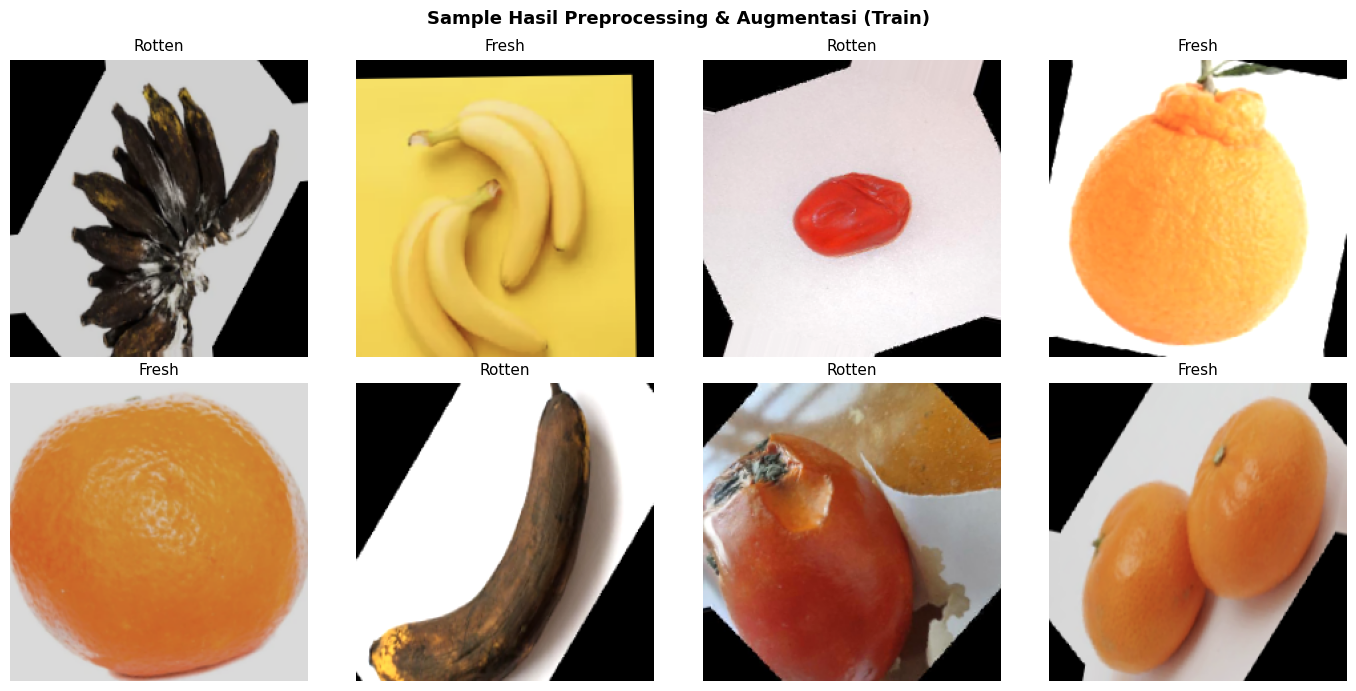

In [44]:
import numpy as np

images, labels = next(train_generator)

print("=== VERIFIKASI PREPROCESSING ===")
print(f"Shape batch: {images.shape}")
print(f"  → {images.shape[0]} gambar, ukuran {images.shape[1]}x{images.shape[2]}, {images.shape[3]} channel (RGB)")
print(f"\nNilai pixel min : {images.min():.4f}  (seharusnya mendekati 0)")
print(f"Nilai pixel max : {images.max():.4f}  (seharusnya mendekati 1)")
print(f"\nDistribusi label dalam batch ini:")
print(f"  Fresh  (0): {(labels == 0).sum()} gambar")
print(f"  Rotten (1): {(labels == 1).sum()} gambar")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

label_names = {0: 'Fresh', 1: 'Rotten'}

for i in range(8):
    axes[i].imshow(images[i])
    axes[i].set_title(f"{label_names[labels[i]]}", fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Hasil Preprocessing & Augmentasi (Train)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Training Model

### Mount Google Drive & Setup

In [45]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/CekFresh_Model'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Model akan disimpan ke: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model akan disimpan ke: /content/drive/MyDrive/CekFresh_Model


### Membangun Arsitektur Model MobileNetV2

Menggunakan Transfer Learning dengan MobileNetV2 yang sudah pre-trained pada ImageNet. Layer base di-freeze terlebih dahulu pada Phase 1, baru di-unfreeze sebagian pada Phase 2 (fine-tuning).

In [46]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

IMG_SHAPE = (224, 224, 3)

# Load MobileNetV2 pretrained ImageNet, tanpa top layer
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze semua layer (Phase 1)

# Bangun classifier di atas base_model
inputs  = tf.keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # Binary: fresh=0, rotten=1

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("\n✅ Model berhasil dibangun!")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total params     : 2,422,081
Trainable params : 164,097

✅ Model berhasil dibangun!


### Phase 1 — Training (Base Model Frozen)

Pada fase ini, seluruh layer MobileNetV2 di-freeze dan hanya layer classifier baru yang dilatih. Tujuannya agar layer classifier baru menyesuaikan diri dengan fitur yang sudah dipelajari MobileNetV2 dari ImageNet.

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/cekfresh_phase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("=" * 55)
print("  PHASE 1 — Training (base model frozen)")
print("=" * 55)

history_p1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks_p1,
    verbose=1
)

print(f"\n✅ Phase 1 selesai!")
print(f"   Best val_accuracy : {max(history_p1.history['val_accuracy']):.4f}")

  PHASE 1 — Training (base model frozen)
Epoch 1/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9320 - loss: 0.1570
Epoch 1: val_accuracy improved from None to 0.96828, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase1_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 927s 2s/step - accuracy: 0.9635 - loss: 0.0909 - val_accuracy: 0.9683 - val_loss: 0.0718 - learning_rate: 0.0010
Epoch 2/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9858 - loss: 0.0355
Epoch 2: val_accuracy improved from 0.96828 to 0.98754, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase1_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 922s 2s/step - accuracy: 0.9865 - loss: 0.0357 - val_accuracy: 0.9875 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 3/10
451/451 ━━━━━━━━━━━━━━━

### Phase 2 — Fine-tuning (Unfreeze 30 Layer Terakhir)

Pada fase ini, 30 layer terakhir MobileNetV2 di-unfreeze dan dilatih ulang dengan learning rate yang sangat kecil (1e-5) agar model dapat menyesuaikan fitur-fitur tingkat tinggi yang spesifik terhadap dataset buah dan sayur.

In [48]:
# Unfreeze 30 layer terakhir base_model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile dengan learning rate lebih kecil
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params setelah unfreeze: {trainable_count:,}")

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/cekfresh_phase2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print("=" * 55)
print("  PHASE 2 — Fine-tuning (30 layer terakhir)")
print("=" * 55)

history_p2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks_p2,
    verbose=1
)

print(f"\n✅ Phase 2 selesai!")
print(f"   Best val_accuracy : {max(history_p2.history['val_accuracy']):.4f}")

Trainable params setelah unfreeze: 1,690,497
  PHASE 2 — Fine-tuning (30 layer terakhir)
Epoch 1/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9290 - loss: 0.3638
Epoch 1: val_accuracy improved from None to 0.99396, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase2_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 1216s 3s/step - accuracy: 0.9585 - loss: 0.1803 - val_accuracy: 0.9940 - val_loss: 0.0145 - learning_rate: 1.0000e-05
Epoch 2/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9856 - loss: 0.0449
Epoch 2: val_accuracy improved from 0.99396 to 0.99698, saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CekFresh_Model/cekfresh_phase2_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 1198s 3s/step - accuracy: 0.9859 - loss: 0.0441 - val_accuracy: 0.9970 - val_loss: 0.0084 - le

### Menyimpan Model Final ke Google Drive

In [49]:
import json

# Simpan model final
model_path = f'{SAVE_DIR}/cekfresh_model.keras'
model.save(model_path)
print(f"✅ Model disimpan  : {model_path}")

# Simpan class names
class_names = {str(v): k for k, v in train_generator.class_indices.items()}
# hasil: {"0": "fresh", "1": "rotten"}
with open(f'{SAVE_DIR}/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print(f"✅ class_names.json disimpan")
print(f"   Isi: {class_names}")
print(f"\nSemua file ada di Google Drive: {SAVE_DIR}/")

✅ Model disimpan  : /content/drive/MyDrive/CekFresh_Model/cekfresh_model.keras
✅ class_names.json disimpan
   Isi: {'0': 'fresh', '1': 'rotten'}

Semua file ada di Google Drive: /content/drive/MyDrive/CekFresh_Model/


### Visualisasi Training History

Menampilkan kurva Accuracy dan Loss dari Phase 1 dan Phase 2 digabungkan untuk melihat perkembangan performa model selama training.

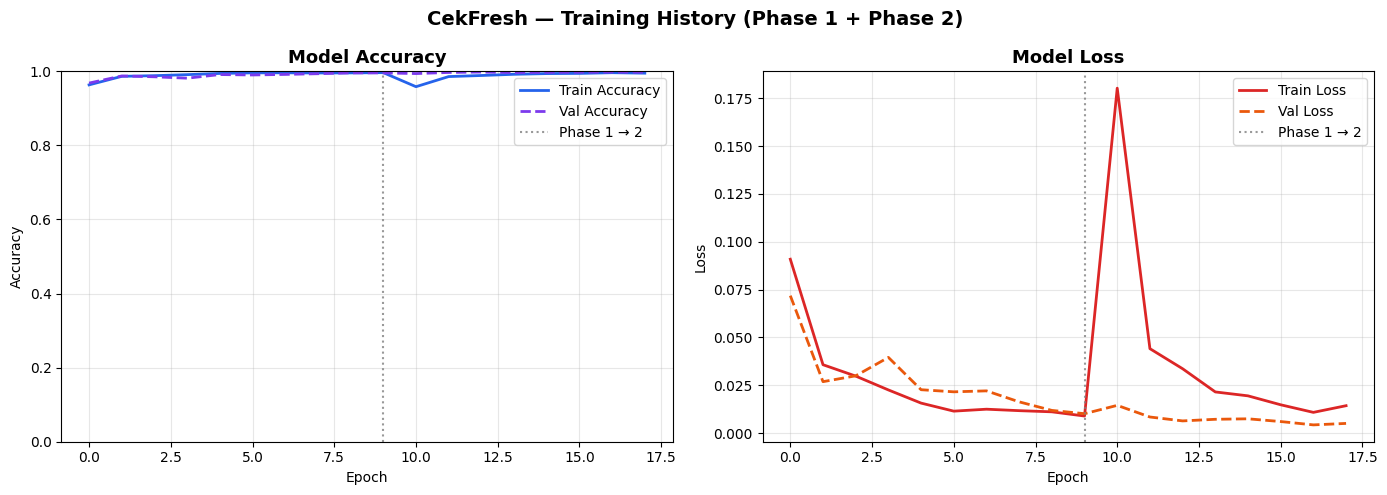

✅ Grafik disimpan: accuracy_loss_curve.png


In [50]:
import matplotlib.pyplot as plt

# Gabungkan history Phase 1 + Phase 2
history_all = {}
for key in history_p1.history:
    history_all[key] = history_p1.history[key] + history_p2.history[key]

phase1_end = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -- Accuracy --
ax1.plot(history_all['accuracy'],     label='Train Accuracy', color='#2563eb', linewidth=2)
ax1.plot(history_all['val_accuracy'], label='Val Accuracy',   color='#7c3aed', linewidth=2, linestyle='--')
ax1.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0, 1])

# -- Loss --
ax2.plot(history_all['loss'],     label='Train Loss', color='#dc2626', linewidth=2)
ax2.plot(history_all['val_loss'], label='Val Loss',   color='#ea580c', linewidth=2, linestyle='--')
ax2.axvline(x=phase1_end - 1, color='gray', linestyle=':', alpha=0.8, label='Phase 1 → 2')
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CekFresh — Training History (Phase 1 + Phase 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/accuracy_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: accuracy_loss_curve.png")

### Evaluasi Model pada Test Set

Mengevaluasi performa model pada data test yang belum pernah dilihat model selama training. Menampilkan classification report dan confusion matrix.

Mengevaluasi model pada test set...
125/125 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step

  TEST ACCURACY  : 0.9970  (99.70%)

Classification Report:
              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00      1832
      Rotten       1.00      1.00      1.00      2160

    accuracy                           1.00      3992
   macro avg       1.00      1.00      1.00      3992
weighted avg       1.00      1.00      1.00      3992

✅ Classification report disimpan


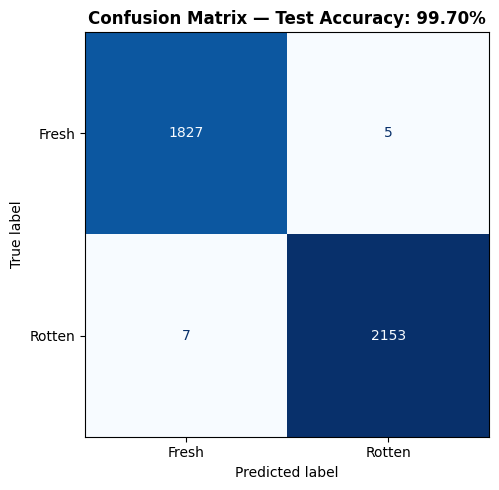

✅ Confusion matrix disimpan

  FILE TERSIMPAN DI GOOGLE DRIVE:
  /content/drive/MyDrive/CekFresh_Model/
    ├── cekfresh_model.keras
    ├── class_names.json
    ├── accuracy_loss_curve.png
    ├── confusion_matrix.png
    └── classification_report.txt


In [51]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
import numpy as np

print("Mengevaluasi model pada test set...")
test_generator.reset()

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_generator.classes

# Accuracy
test_acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*50}")
print(f"  TEST ACCURACY  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*50}")

# Classification Report
class_labels = ['Fresh', 'Rotten']
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(report)

# Simpan report
with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f"CekFresh — Classification Report\n")
    f.write(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n\n")
    f.write(report)
print("✅ Classification report disimpan")

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
fig2, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan")

print(f"\n{'='*50}")
print("  FILE TERSIMPAN DI GOOGLE DRIVE:")
print(f"  {SAVE_DIR}/")
print("    ├── cekfresh_model.keras")
print("    ├── class_names.json")
print("    ├── accuracy_loss_curve.png")
print("    ├── confusion_matrix.png")
print("    └── classification_report.txt")
print(f"{'='*50}")